# SO(3) Equivariant MLP for 3D Vectors

This notebook demonstrates the soft equivariance framework for a set of 3D vectors (e.g. coordinates or velocities). We will operate on 5 input vectors simultaneously (dimension 15), extracting a single invariant scalar or producing a single equivariant 3D vector.

In [10]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.animation as animation
from IPython.display import Image, display, HTML

## 1. Implement SO3Constraints Class

We update `SO3Constraints` to accept a number of input and output vectors. It constructs block-diagonal generator matrices since the group action applies to each vector identically.

In [11]:
from softeq.equi_utils.base_constraints import BaseConstraints
from softeq.utils.decompositions import schur_decomposition, svd_decomposition

class SO3Constraints(BaseConstraints):
    def __init__(self, n_vectors_in=1, n_vectors_out=1, decomposition_method='svd'):
        self.n_vectors_in = n_vectors_in
        self.n_vectors_out = n_vectors_out
        self.input_size = n_vectors_in * 3
        self.output_size = n_vectors_out * 3
        self.decomposition_method = decomposition_method
        self.create_unit_group_action_matrix()
        self.create_unit_group_action_forward_difference_matrix()
    
    def create_unit_group_action_matrix(self):
        L_x = torch.tensor([[0,0,0],[0,0,-1],[0,1,0]], dtype=torch.float32)
        L_y = torch.tensor([[0,0,1],[0,0,0],[-1,0,0]], dtype=torch.float32)
        L_z = torch.tensor([[0,-1,0],[1,0,0],[0,0,0]], dtype=torch.float32)
        
        def block_diag(mat, n):
            if n == 1: return mat
            return torch.block_diag(*[mat for _ in range(n)])
            
        self.unit_group_action_matrices = [block_diag(m, self.n_vectors_in) for m in [L_x, L_y, L_z]]
        self.unit_group_action_matrix = self.unit_group_action_matrices[2]
        
        if self.output_size is not None:
            self.unit_group_action_matrices_out = [block_diag(m, self.n_vectors_out) for m in [L_x, L_y, L_z]]
            self.unit_group_action_matrix_out = self.unit_group_action_matrices_out[2]
        else:
            self.unit_group_action_matrices_out = None
            self.unit_group_action_matrix_out = None
            
    def create_unit_group_action_forward_difference_matrix(self):
        self.forward_difference_matrices = self.unit_group_action_matrices
        self.forward_difference_matrix = self.unit_group_action_matrix
        if self.output_size is not None:
            self.forward_difference_matrices_out = self.unit_group_action_matrices_out
            self.forward_difference_matrix_out = self.unit_group_action_matrix_out
        else:
            self.forward_difference_matrices_out = None
            self.forward_difference_matrix_out = None
            
    def get_decomposition(self, rep='input', method=None, return_original=False):
        matrices = self.forward_difference_matrices if rep == 'input' else self.forward_difference_matrices_out
        decomp_method = method if method is not None else self.decomposition_method
        decompositions = []
        for matrix in matrices:
            if decomp_method == 'schur':
                s_values, right = schur_decomposition(matrix, return_original=return_original)
                left = right
            elif decomp_method == 'svd':
                left, s_values, right = svd_decomposition(matrix)
            decompositions.append((left, s_values, right))
        return decompositions
        
    def get_equivariant_condition_matrix(self, diagonal_only=True):
        metrices = []
        if diagonal_only:
            for i, matrix in enumerate(self.forward_difference_matrices):
                out_matrix = self.forward_difference_matrices_out[i]
                d = matrix.shape[0]
                eye_in = torch.eye(d, device=matrix.device, dtype=matrix.dtype)
                eye_out = torch.eye(self.output_size, device=matrix.device, dtype=matrix.dtype)
                condition = torch.kron(matrix.T.contiguous(), eye_out) - torch.kron(eye_in, out_matrix.contiguous())
                metrices.append(condition)
        return metrices


## 2. Parameterized Invariant and Equivariant Layers
We parameterize `FLinear` to work on 5 input vectors (dimension 15).

In [12]:
from softeq.layers.flinear import FLinear
from softeq.equi_utils.inv_projector import InvariantProjector
from softeq.equi_utils.equi_projectors import MultiGeneratorEquivariantProjectorviaSVD

def get_so3_invariant_filter(n_vectors_in=5, soft_threshold=0.1):
    so3 = SO3Constraints(n_vectors_in=n_vectors_in)
    stacked_h = torch.cat(so3.forward_difference_matrices, dim=1)
    stacked_v = torch.cat(so3.forward_difference_matrices, dim=0)
    U_l, S_l, _ = svd_decomposition(stacked_h)
    _, S_r, V_r = svd_decomposition(stacked_v)
    min_len = min(len(S_l), len(S_r))
    vals = S_l[:min_len] + S_r[:min_len]
    return InvariantProjector(U_l, V_r, vals, softness=soft_threshold, hard_mask=True, hard=True, debug=False)

def get_so3_equivariant_filter(n_vectors_in=5, n_vectors_out=1, soft_threshold=0.0):
    st = float(soft_threshold)
    constraints = SO3Constraints(n_vectors_in=n_vectors_in, n_vectors_out=n_vectors_out)
    condition_list = constraints.get_equivariant_condition_matrix(diagonal_only=True)
    stacked_condition = torch.cat(condition_list, dim=0)
    U, S, V = svd_decomposition(stacked_condition)
    inv_filter = InvariantProjector(V, V, S[: V.shape[1]], softness=st, hard_mask=True, hard=True, debug=False)
    return MultiGeneratorEquivariantProjectorviaSVD(inv_filter, constraints.input_size, constraints.output_size, st)

class SO3InvariantMLP(nn.Module):
    def __init__(self, n_vectors_in=5, hidden_dim=16, soft_threshold=0.1):
        super().__init__()
        self.n_vectors_in = n_vectors_in
        self.fc1 = FLinear(n_vectors_in * 3, hidden_dim, filter=get_so3_invariant_filter(n_vectors_in, soft_threshold))
        self.fc2 = nn.Linear(hidden_dim, 1) # Maps to single scalar
    def forward(self, x):
        # x shape: (batch_size, n_vectors_in * 3)
        return self.fc2(self.fc1(x))

def create_so3_equivariant_layer(n_vectors_in=5, n_vectors_out=1, soft_threshold=0.0):
    filt = get_so3_equivariant_filter(n_vectors_in, n_vectors_out, soft_threshold)
    return FLinear(n_vectors_in * 3, n_vectors_out * 3, bias=False, enforce_equivariance=True, in_channels=1, out_channels=1, filter=filt)


## 3. Generate Set of Co-Rotating Vectors
We plot 5 vectors from the origin.

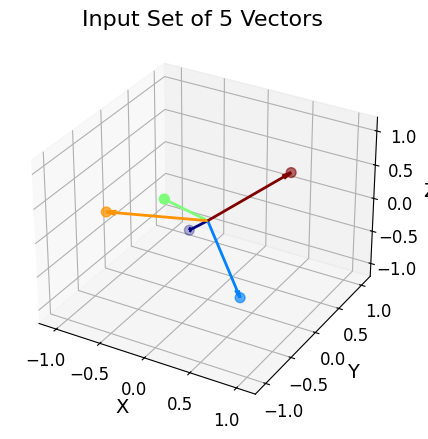

In [13]:
def get_rodrigues_rotation(axis, angle):
    axis = axis / np.linalg.norm(axis)
    K = np.array([[0, -axis[2], axis[1]],
                  [axis[2], 0, -axis[0]],
                  [-axis[1], axis[0], 0]])
    R = np.eye(3) + np.sin(angle) * K + (1 - np.cos(angle)) * K @ K
    return torch.tensor(R, dtype=torch.float32)

def generate_vector_set(n_vectors=5, batch_size=1):
    phi = np.random.uniform(0, 2*np.pi, (batch_size, n_vectors))
    theta = np.arccos(np.random.uniform(-1, 1, (batch_size, n_vectors)))
    x = np.sin(theta) * np.cos(phi)
    y = np.sin(theta) * np.sin(phi)
    z = np.cos(theta)
    return torch.tensor(np.stack([x, y, z], axis=-1), dtype=torch.float32)

torch.manual_seed(42)
np.random.seed(42)

n_vectors = 5
pts = generate_vector_set(n_vectors=n_vectors, batch_size=1)[0] # Shape: (5, 3)
colors = plt.cm.jet(np.linspace(0, 1, len(pts)))

# Visualize the 5 vectors
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection='3d')
ax.quiver(np.zeros(n_vectors), np.zeros(n_vectors), np.zeros(n_vectors), 
          pts[:,0], pts[:,1], pts[:,2], color=colors, arrow_length_ratio=0.1, linewidth=2)
ax.scatter(pts[:,0], pts[:,1], pts[:,2], color=colors, s=50) # Heads of arrows

ax.set_xlim([-1.2, 1.2]); ax.set_ylim([-1.2, 1.2]); ax.set_zlim([-1.2, 1.2])
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.set_title('Input Set of 5 Vectors')
plt.show()


## 5. Invariance Error Visualization (GIF)
Showing the single scalar output error increasing as the set of vectors rotates.

last_basis_idx and total basis: -1 15
last_basis_idx and total basis: -1 15
last_basis_idx and total basis: -1 15
last_basis_idx and total basis: -1 15
last_basis_idx and total basis: -1 15
last_basis_idx and total basis: -1 15
last_basis_idx and total basis: -1 15
last_basis_idx and total basis: -1 15
last_basis_idx and total basis: -1 15
last_basis_idx and total basis: -1 15
last_basis_idx and total basis: 1 15
last_basis_idx and total basis: 1 15
last_basis_idx and total basis: 1 15
last_basis_idx and total basis: 1 15
last_basis_idx and total basis: 1 15
last_basis_idx and total basis: 1 15
last_basis_idx and total basis: 1 15
last_basis_idx and total basis: 1 15
last_basis_idx and total basis: 1 15
last_basis_idx and total basis: 1 15
last_basis_idx and total basis: 4 15
last_basis_idx and total basis: 4 15
last_basis_idx and total basis: 4 15
last_basis_idx and total basis: 4 15
last_basis_idx and total basis: 4 15
last_basis_idx and total basis: 4 15
last_basis_idx and total bas

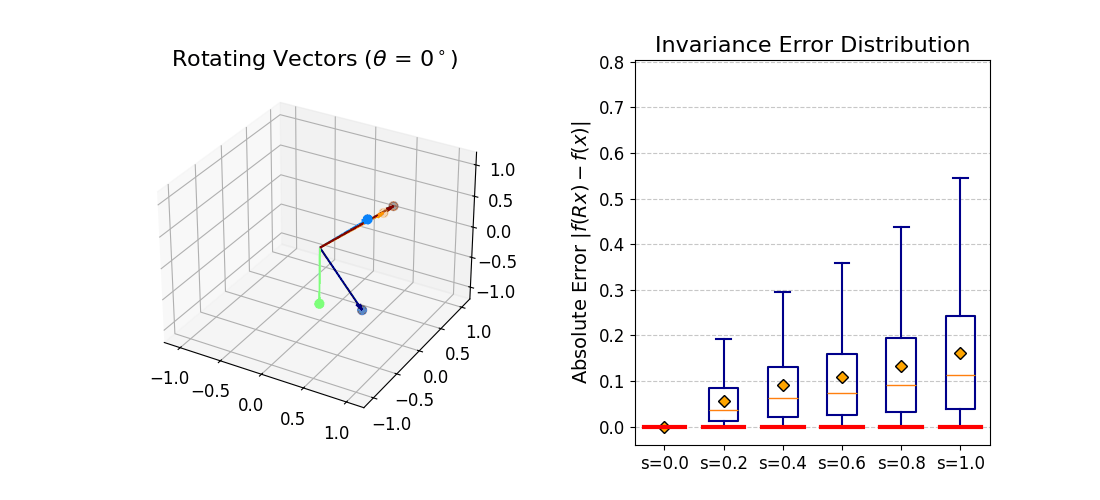

In [14]:
angles = np.linspace(0, 2*np.pi, 40)
rot_axis = np.array([0.0, 0.0, 1.0])

fig_inv = plt.figure(figsize=(11, 5)) # Slightly wider for gap
fig_inv.subplots_adjust(wspace=0.4)   # Add horizontal gap
ax1 = fig_inv.add_subplot(121, projection='3d')
ax2 = fig_inv.add_subplot(122)

# Generate 500 batches of points and 10 model initializations
n_batches = 500
n_inits = 10
pts_batch_eval = generate_vector_set(n_vectors=5, batch_size=n_batches)
flat_pts_batch_eval = pts_batch_eval.view(n_batches, 15)

# Array of models spanning from hard (0.0) to completely soft (1.0)
softness_vals = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

# models_inv[s_idx][i_idx] contains the i-th init for the s-th softness value
models_inv = [
    [SO3InvariantMLP(n_vectors_in=5, hidden_dim=16, soft_threshold=s).eval() for _ in range(n_inits)] 
    for s in softness_vals
]

# Precompute base outputs to avoid recomputing every frame
base_outs = [
    [m(flat_pts_batch_eval).detach() for m in inits]
    for inits in models_inv
]

# Colors and labels
bar_labels = [f"s={s:.1f}" for s in softness_vals]
pts_vis = pts_batch_eval[0]
colors_vis = plt.cm.jet(np.linspace(0, 1, len(pts_vis)))

# Pre-calculate errors over all rotations to create the static boxplot
print("Pre-calculating error distributions for boxplots...")
global_errors = [[] for _ in softness_vals]
frame_mean_errors = [[] for _ in softness_vals]

for an in angles:
    R = get_rodrigues_rotation(rot_axis, an)
    rot_pts_batch = (pts_batch_eval @ R.T).contiguous().view(n_batches, 15)
    for s_idx in range(len(softness_vals)):
        errs = []
        for i_idx in range(n_inits):
            out = models_inv[s_idx][i_idx](rot_pts_batch).detach()
            errs.append((out - base_outs[s_idx][i_idx]).abs().view(-1))
        
        frame_errs_tensor = torch.cat(errs) # shape: (5000,)
        global_errors[s_idx].append(frame_errs_tensor)
        frame_mean_errors[s_idx].append(frame_errs_tensor.mean().item())

global_errors_numpy = [torch.cat(e).numpy() for e in global_errors] # 6 arrays of shape 200,000

# Dynamically set y-axis scale based on 99th percentile to exclude extreme outliers
max_err = max([np.percentile(e, 99) for e in global_errors_numpy])
y_max = max(0.5, float(max_err * 1.2))

def update_inv(frame):
    ax1.clear(); ax2.clear()
    an = angles[frame]
    R = get_rodrigues_rotation(rot_axis, an)
    
    # Rotate visualization points
    rot_pts_vis = pts_vis @ R.T # (5, 3)
    
    # Left: Rotating Vectors (Visualization of 1 batch)
    x, y, z = rot_pts_vis[:,0], rot_pts_vis[:,1], rot_pts_vis[:,2]
    ax1.quiver(np.zeros(len(x)), np.zeros(len(y)), np.zeros(len(z)), 
               x, y, z, color=colors_vis, arrow_length_ratio=0.1, linewidth=1.5)
    ax1.scatter(x, y, z, c=colors_vis, s=40)
    ax1.set_xlim([-1.2, 1.2]); ax1.set_ylim([-1.2, 1.2]); ax1.set_zlim([-1.2, 1.2])
    # r-string to properly render \theta in matplotlib mathmode
    ax1.set_title(rf"Rotating Vectors ($\theta$ = {np.degrees(an):.0f}$^\circ$)")

    # Right: Static Box Plot tracking current mean error
    boxprops = dict(linewidth=1.5, color='darkblue')
    whiskerprops = dict(linewidth=1.5, color='darkblue')
    capprops = dict(linewidth=1.5, color='darkblue')
    meanprops = dict(marker='D', markeredgecolor='black', markerfacecolor='orange')
    
    ax2.boxplot(global_errors_numpy, positions=np.arange(len(softness_vals)), 
                showfliers=False, widths=0.5, showmeans=True,
                boxprops=boxprops, whiskerprops=whiskerprops, 
                capprops=capprops, meanprops=meanprops)
                
    # Track the current mean error with a horizontal line
    for s_idx in range(len(softness_vals)):
        current_mean = frame_mean_errors[s_idx][frame]
        ax2.plot([s_idx - 0.35, s_idx + 0.35], [current_mean, current_mean], color='red', linewidth=3, zorder=5)

    ax2.set_xticks(np.arange(len(softness_vals)))
    ax2.set_xticklabels(bar_labels)
    ax2.set_ylim([-y_max*0.05, y_max])
    ax2.set_ylabel(r"Absolute Error $|f(Rx) - f(x)|$")
    ax2.set_title(f"Invariance Error Distribution")
    ax2.grid(True, axis='y', linestyle='--', alpha=0.7)
    
ani_inv = animation.FuncAnimation(fig_inv, update_inv, frames=len(angles), interval=100)
gif_inv_path = './figs/invariance_demo.gif'
ani_inv.save(gif_inv_path, writer='pillow')
plt.close(fig_inv)

display(Image(filename=gif_inv_path))

## 6. Equivariance Error Visualization (GIF)
Comparing expected mapping $R \cdot f(x)$ with actual $f(R \cdot x)$ for different softness parameters $s$.

last_basis_idx and total basis: tensor(4) 45
last_basis_idx and total basis: tensor(4) 45
last_basis_idx and total basis: tensor(4) 45
last_basis_idx and total basis: tensor(4) 45
last_basis_idx and total basis: tensor(4) 45
last_basis_idx and total basis: tensor(4) 45
last_basis_idx and total basis: tensor(4) 45
last_basis_idx and total basis: tensor(4) 45
last_basis_idx and total basis: tensor(4) 45
last_basis_idx and total basis: tensor(4) 45
last_basis_idx and total basis: tensor(7) 45
last_basis_idx and total basis: tensor(7) 45
last_basis_idx and total basis: tensor(7) 45
last_basis_idx and total basis: tensor(7) 45
last_basis_idx and total basis: tensor(7) 45
last_basis_idx and total basis: tensor(7) 45
last_basis_idx and total basis: tensor(7) 45
last_basis_idx and total basis: tensor(7) 45
last_basis_idx and total basis: tensor(7) 45
last_basis_idx and total basis: tensor(7) 45
last_basis_idx and total basis: tensor(19) 45
last_basis_idx and total basis: tensor(19) 45
last_bas

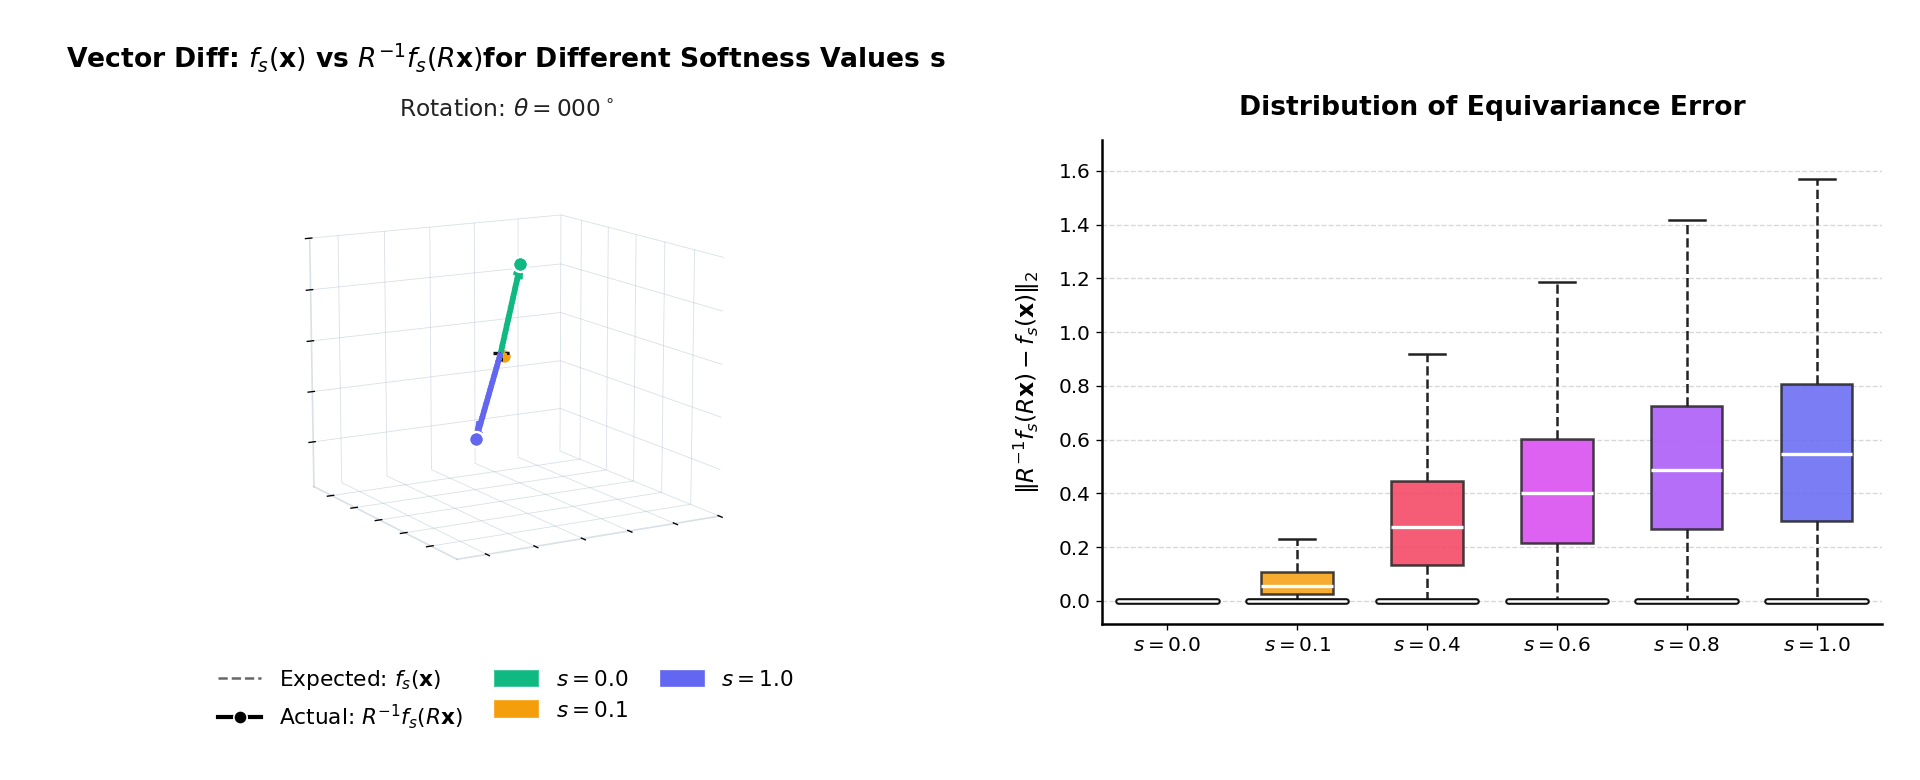

In [15]:
# CVPR-Level Visualization Setup
plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'legend.fontsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
})

fig_eq = plt.figure(figsize=(16, 6.5), dpi=120)
# Reserve space at top for titles, and ample space at bottom for the new horizontal legend
fig_eq.subplots_adjust(wspace=0.15, left=0.02, right=0.98, top=0.82, bottom=0.20) 

import matplotlib.gridspec as gridspec
gs = fig_eq.add_gridspec(1, 2, width_ratios=[1.2, 1])

ax1 = fig_eq.add_subplot(gs[0], projection='3d')
ax2 = fig_eq.add_subplot(gs[1])

# Generate sets for evaluation
n_batches = 500
n_inits = 10
pts_batch_eval = generate_vector_set(n_vectors=5, batch_size=n_batches)
flat_pts_batch_eval = pts_batch_eval.view(n_batches, 15)

softness_vals = [0.0, 0.1, 0.4, 0.6, 0.8, 1.0]

# High-contrast professional CVPR palette mapping to softness
BOX_COLORS = ['#10b981', '#f59e0b', '#f43f5e', '#d946ef', '#a855f7', '#6366f1']
bar_labels = [rf"$s={s:.1f}$" for s in softness_vals]

# Initialize models
models_eq = [
    [create_so3_equivariant_layer(n_vectors_in=5, n_vectors_out=1, soft_threshold=s).eval() for _ in range(n_inits)] 
    for s in softness_vals
]

# Base predictions to compute Expected f(x)
base_outs = [
    [m(flat_pts_batch_eval).detach() for m in inits]
    for inits in models_eq
]

print("Pre-calculating equivariance error distributions for boxplots...")
global_errors_eq = [[] for _ in softness_vals]
frame_mean_errors_eq = [[] for _ in softness_vals]

for an in angles:
    R = get_rodrigues_rotation(rot_axis, an)
    rot_pts_batch = (pts_batch_eval @ R.T).contiguous().view(n_batches, 15)
    
    for s_idx in range(len(softness_vals)):
        errs = []
        for i_idx in range(n_inits):
            out = models_eq[s_idx][i_idx](rot_pts_batch).detach()
            
            # Unrotate the output f(Rx) -> f(Rx) @ R 
            out_unrotated = out @ R
            expected = base_outs[s_idx][i_idx] # This is f(x)
            
            # Take standard norm difference across the output vector
            errs.append(torch.norm(out_unrotated - expected, dim=1))
            
        frame_errs_tensor = torch.cat(errs) # shape: (5000,)
        global_errors_eq[s_idx].append(frame_errs_tensor)
        frame_mean_errors_eq[s_idx].append(frame_errs_tensor.mean().item())

global_errors_eq_numpy = [torch.cat(e).numpy() for e in global_errors_eq]

max_err_eq = max([np.percentile(e, 99) for e in global_errors_eq_numpy])
y_max_eq = max(0.5, float(max_err_eq * 1.2))

# Select a single init of a few models to demonstrate the divergence of output vectors
single_pt = pts_batch_eval[0:1]      

# Extract the specific expected f(x) for each model we are visualizing (only s=0.0, s=0.1, s=1.0)
expected_s0  = base_outs[0][0][0:1]  
expected_s1  = base_outs[1][0][0:1]  
expected_s10 = base_outs[5][0][0:1]  

# Calculate tight bounding bounds exactly localized only to where the vectors travel
all_x, all_y, all_z = [], [], []
for an in angles:
    R_tmp = get_rodrigues_rotation(rot_axis, an)
    rot_pt_tmp = (single_pt @ R_tmp.T).contiguous().view(1, 15)
    
    act_s0_tmp = models_eq[0][0](rot_pt_tmp).detach() @ R_tmp 
    act_s1_tmp = models_eq[1][0](rot_pt_tmp).detach() @ R_tmp 
    act_s10_tmp= models_eq[5][0](rot_pt_tmp).detach() @ R_tmp
    
    for vec in [expected_s0, expected_s1, expected_s10, act_s0_tmp, act_s1_tmp, act_s10_tmp]:
        v_np = vec.squeeze().numpy()
        all_x.append(v_np[0])
        all_y.append(v_np[1])
        all_z.append(v_np[2])

# Crop the empty space around the origin rigorously to fit exactly what is plotted
min_x, max_x = min(all_x), max(all_x)
min_y, max_y = min(all_y), max(all_y)
min_z, max_z = min(all_z), max(all_z)

# Expand bounds slightly (5%) so markers stay inside
pad_x = (max_x - min_x) * 0.05
pad_y = (max_y - min_y) * 0.05
pad_z = (max_z - min_z) * 0.05

from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

# Dynamic camera view based on the mean of the expected vectors avoiding (0,0) division
v_sum = (expected_s0 + expected_s1 + expected_s10).squeeze().numpy()
x_cam, y_cam, z_cam = v_sum
VIEW_ELEV = np.degrees(np.arctan2(z_cam, np.hypot(x_cam, y_cam)))
VIEW_AZIM = np.degrees(np.arctan2(y_cam, x_cam))

def plot_styled_boxplots(ax, data, positions, labels, colors, means_track):
    bplot = ax.boxplot(data, positions=positions, showfliers=False, widths=0.55, 
                       patch_artist=True, # Fill with color
                       meanprops={'marker': 'None'})
    
    for patch, color in zip(bplot['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.85)
        patch.set_edgecolor('#222')
        patch.set_linewidth(1.5)
        
    for whisker in bplot['whiskers']:
        whisker.set_color('#222')
        whisker.set_linewidth(1.5)
        whisker.set_linestyle('--')
        
    for cap in bplot['caps']:
        cap.set_color('#222')
        cap.set_linewidth(1.5)
        
    for median in bplot['medians']:
        median.set_color('#fff')
        median.set_linewidth(2.0)
        
    # Draw high-contrast tracking lines for the mean across each box
    for s_idx, current_mean in enumerate(means_track):
        ax.plot([s_idx - 0.38, s_idx + 0.38], [current_mean, current_mean], color='#111', linewidth=4, zorder=6, solid_capstyle='round')
        ax.plot([s_idx - 0.38, s_idx + 0.38], [current_mean, current_mean], color='#fff', linewidth=1.5, zorder=7, solid_capstyle='round')

    ax.set_xticks(positions)
    ax.set_xticklabels(labels)
    ax.set_ylim([-y_max_eq*0.05, y_max_eq])
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.grid(True, axis='y', linestyle='--', alpha=0.5, zorder=0)

def plot_overlapping_pairs(ax, pairs_dict, angle):
    ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
    ax.yaxis.set_pane_color((1.0, 1.0, 0.95, 0.0))
    ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
    
    grid_color = (0.5, 0.6, 0.7, 0.3)
    grid_lw = 0.5
    ax.xaxis._axinfo["grid"].update({'color': grid_color, 'linewidth': grid_lw})
    ax.yaxis._axinfo["grid"].update({'color': grid_color, 'linewidth': grid_lw})
    ax.zaxis._axinfo["grid"].update({'color': grid_color, 'linewidth': grid_lw})
    
    for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
        axis.line.set_color(grid_color)
        axis.line.set_linewidth(1.0)
        
    ax.set_xticklabels([]); ax.set_yticklabels([]); ax.set_zticklabels([])
    ax.scatter([0], [0], [0], color='#111', marker='+', s=100, linewidth=2, zorder=1)

    for name, (expected_vec, actual_vec, color) in pairs_dict.items():
        v_exp = expected_vec.squeeze().numpy()
        v_act = actual_vec.squeeze().numpy()
        
        ax.plot([0, v_exp[0]], [0, v_exp[1]], [0, v_exp[2]], color=color, linestyle='--', linewidth=2.0, alpha=0.5, zorder=2)
        ax.scatter(v_exp[0], v_exp[1], v_exp[2], color=color, marker='o', s=25, alpha=0.5, zorder=3)
        
        ax.quiver(0, 0, 0, v_act[0], v_act[1], v_act[2], color=color, arrow_length_ratio=0.15, linewidth=3.5, zorder=4)
        ax.scatter(v_act[0], v_act[1], v_act[2], facecolor=color, edgecolor='white', marker='o', s=80, linewidth=1.5, zorder=5)

    # Use a narrower view angle to naturally "zoom in" natively in matplotlib
    ax.view_init(elev=VIEW_ELEV, azim=VIEW_AZIM) 
    
    # Restrict axes explicitly to asymmetric boundaries, stripping massive white space 
    ax.set_xlim([min_x - pad_x, max_x + pad_x])
    ax.set_ylim([min_y - pad_y, max_y + pad_y])
    ax.set_zlim([min_z - pad_z, max_z + pad_z])
    
    # Ensure physical aspect ratio reflects exact data ratios so no arbitrary mathematical distortion occurs
    ax.set_box_aspect((max_x - min_x + 2*pad_x, 
                       max_y - min_y + 2*pad_y, 
                       max_z - min_z + 2*pad_z))
    
    ax.text2D(0.5, 1.15, "Vector Diff: " + r"$f_s(\mathbf{x})$ vs $R^{-1}f_s(R\mathbf{x})$" + "for Different Softness Values s", 
              transform=ax.transAxes, ha='center', fontsize=16, fontweight='bold')
    ax.text2D(0.5, 1.05, rf"Rotation: $\theta = {np.degrees(angle):03.0f}^\circ$", 
              transform=ax.transAxes, ha='center', fontsize=14, color='#222')

# Create the specific legend for axis 1 (left gif)
styled_legend_handles = [
    [Line2D([0], [0], color='black', lw=1.5, linestyle='--', alpha=0.6, label=rf"Expected: $f_s(\mathbf{{x}})$"),
     Line2D([0], [0], color='black', lw=2.5, marker='o', markeredgecolor='white', markersize=8, label=rf"Actual: $R^{{-1}}f_s(R\mathbf{{x}})$")],
    [mpatches.Patch(color=BOX_COLORS[0], label=r"$s=0.0$"),
     mpatches.Patch(color=BOX_COLORS[1], label=r"$s=0.1$"),
     mpatches.Patch(color=BOX_COLORS[5], label=r"$s=1.0$")]
]
flat_handles = styled_legend_handles[0] + styled_legend_handles[1]

def update_eq(frame):
    ax1.clear(); ax2.clear()
    an = angles[frame]
    R = get_rodrigues_rotation(rot_axis, an)
    
    # Redraw Legend per frame
    ax1.legend(handles=flat_handles, loc='upper center', bbox_to_anchor=(0.5, -0.05), 
               ncol=3, frameon=False, fontsize=13, columnspacing=1.5)
    
    # 1. 3D Plot side
    rot_pt = (single_pt @ R.T).contiguous().view(1, 15)
    actual_s0   = models_eq[0][0](rot_pt).detach() @ R
    actual_s1   = models_eq[1][0](rot_pt).detach() @ R
    actual_s10  = models_eq[5][0](rot_pt).detach() @ R
    
    pairs = {
        "s=0.0": (expected_s0,  actual_s0,  BOX_COLORS[0]),
        "s=0.1": (expected_s1,  actual_s1,  BOX_COLORS[1]),
        "s=1.0": (expected_s10, actual_s10, BOX_COLORS[5])
    }
    plot_overlapping_pairs(ax1, pairs, angle=an)
    
    # 2. Boxplot Error Distribution side
    current_means = [frame_mean_errors_eq[i][frame] for i in range(len(softness_vals))]
    plot_styled_boxplots(ax2, global_errors_eq_numpy, np.arange(len(softness_vals)), bar_labels, BOX_COLORS, current_means)
    
    ax2.set_title("Distribution of Equivariance Error", fontweight='bold', pad=15)
    ax2.set_ylabel(r"$\|R^{-1}f_s(R\mathbf{x}) - f_s(\mathbf{x})\|_2$", fontweight='bold', labelpad=10)

ani_eq = animation.FuncAnimation(fig_eq, update_eq, frames=len(angles), interval=100)
gif_eq_path = './figs/equivariance_demo_pro.gif'
ani_eq.save(gif_eq_path, writer='pillow')
plt.close(fig_eq)

display(Image(filename=gif_eq_path))

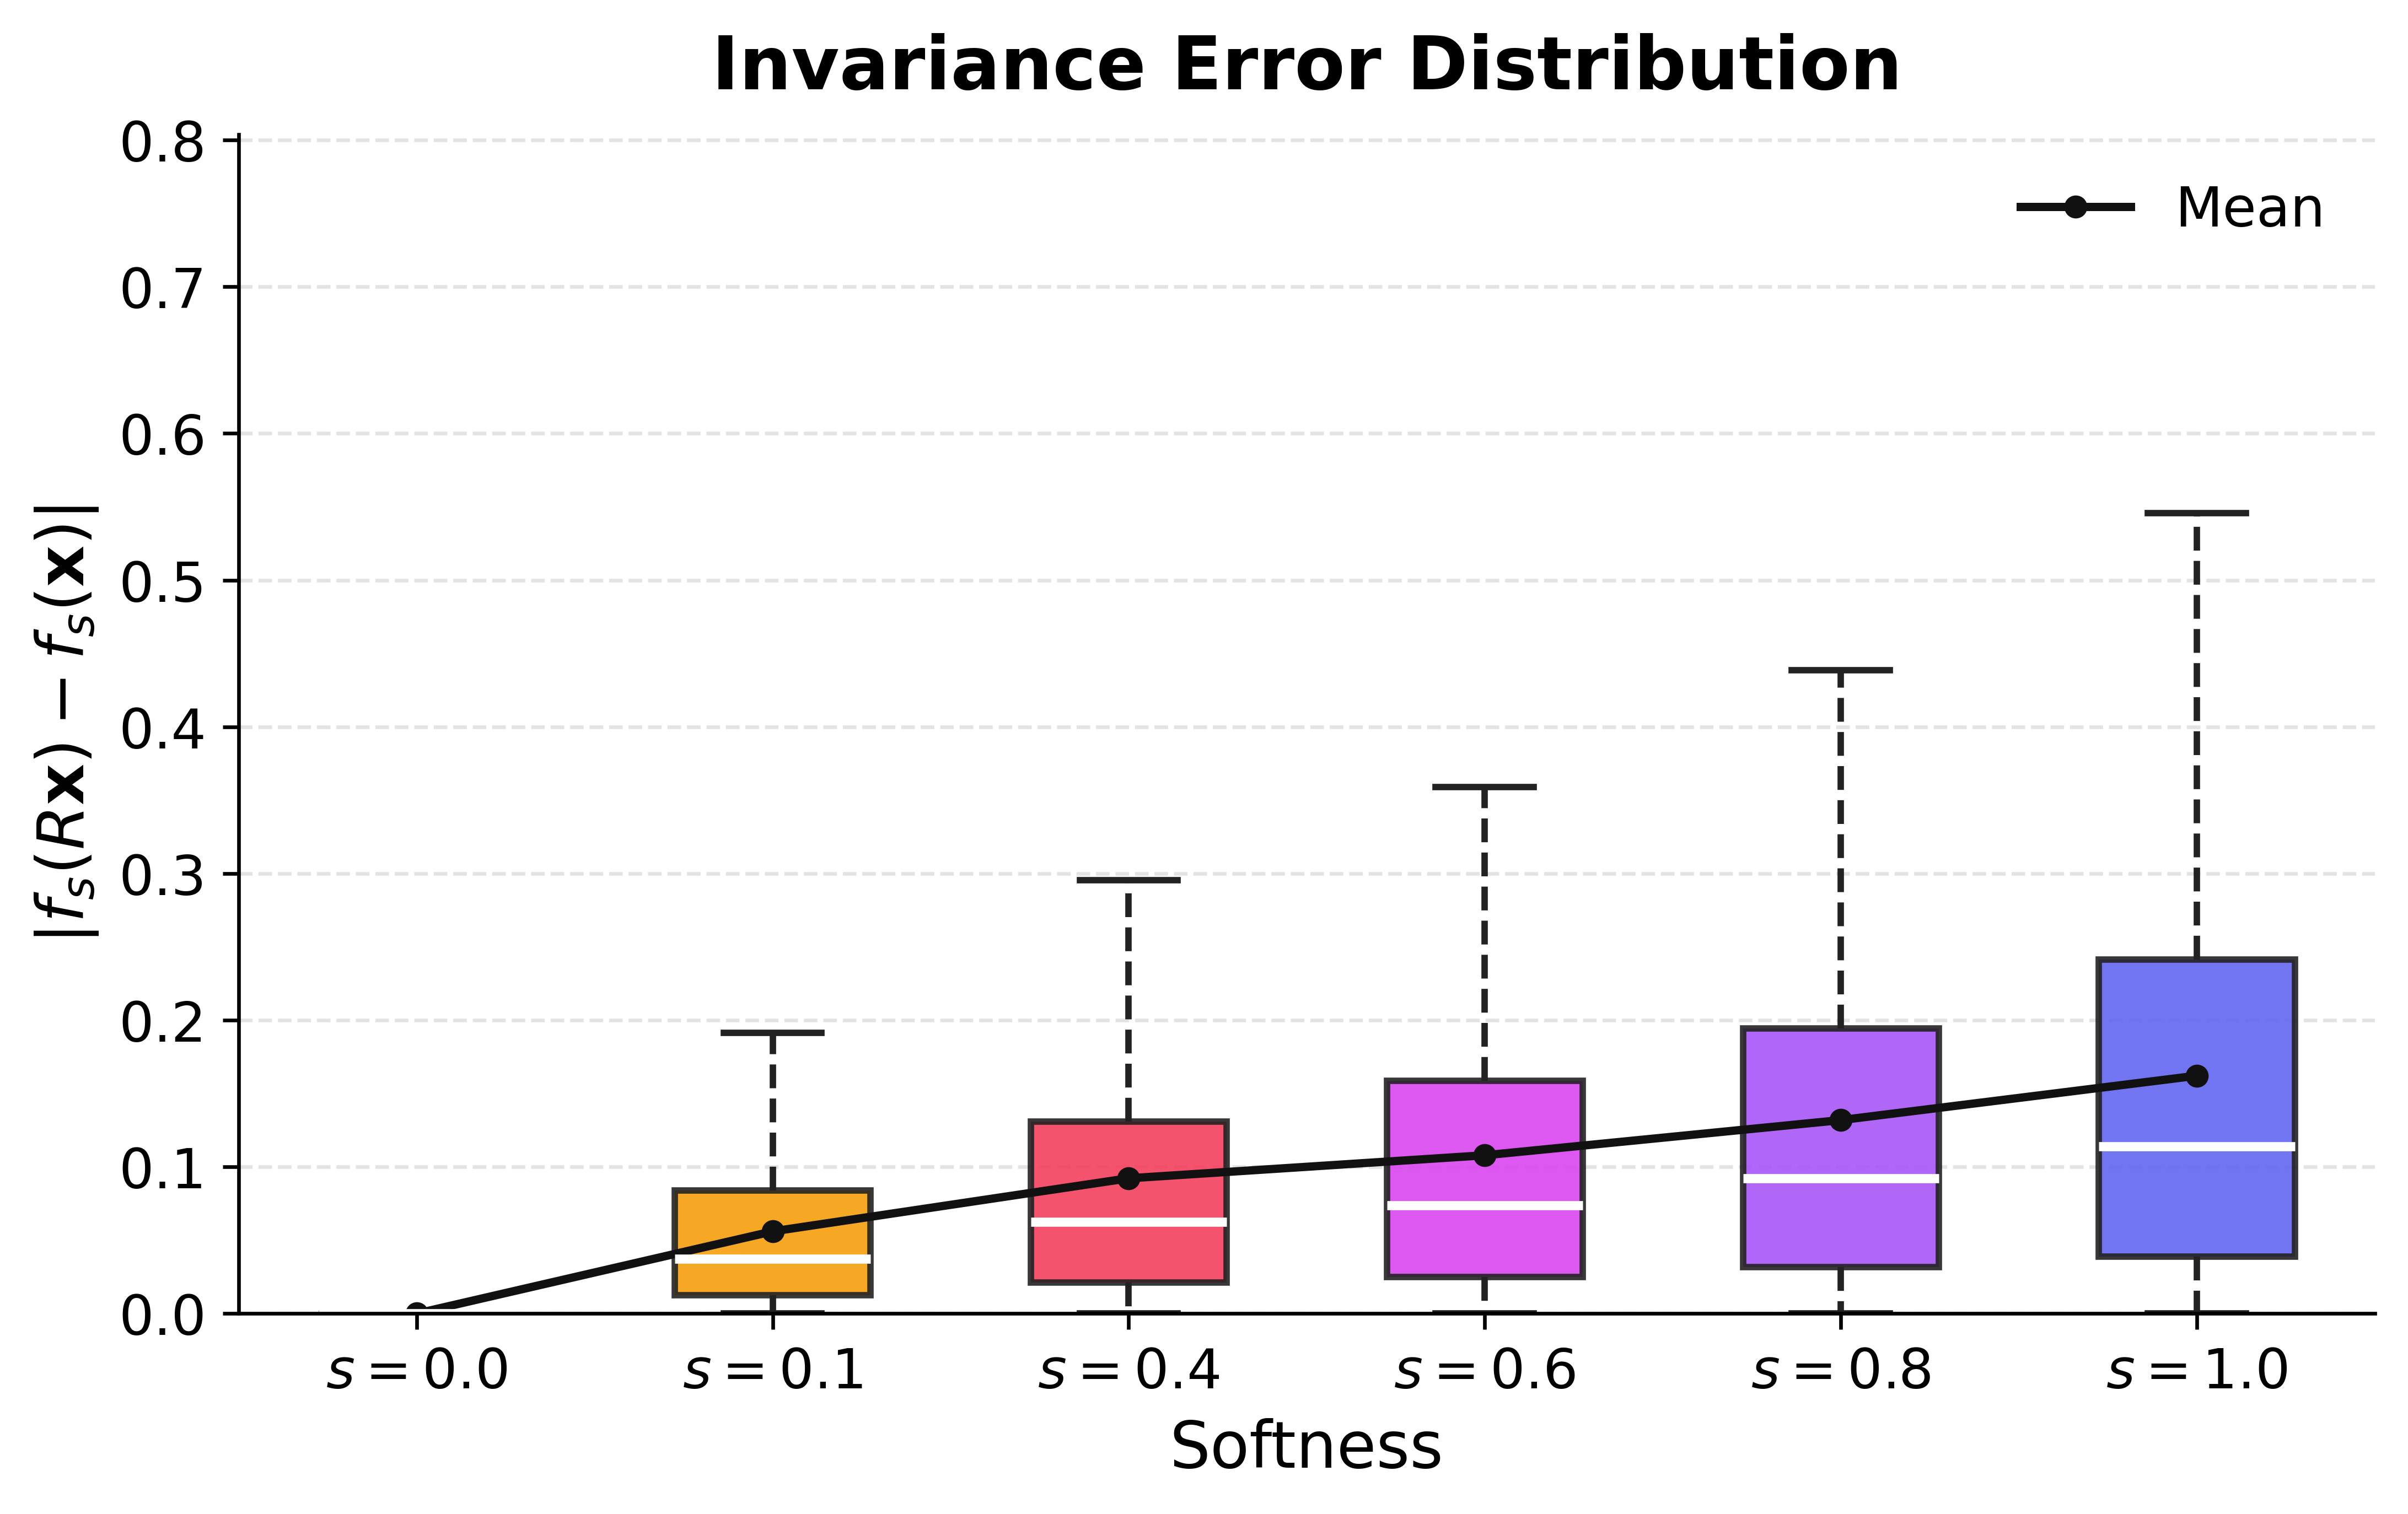

Saved: ./figs/invariance_boxplot_static_600dpi.png


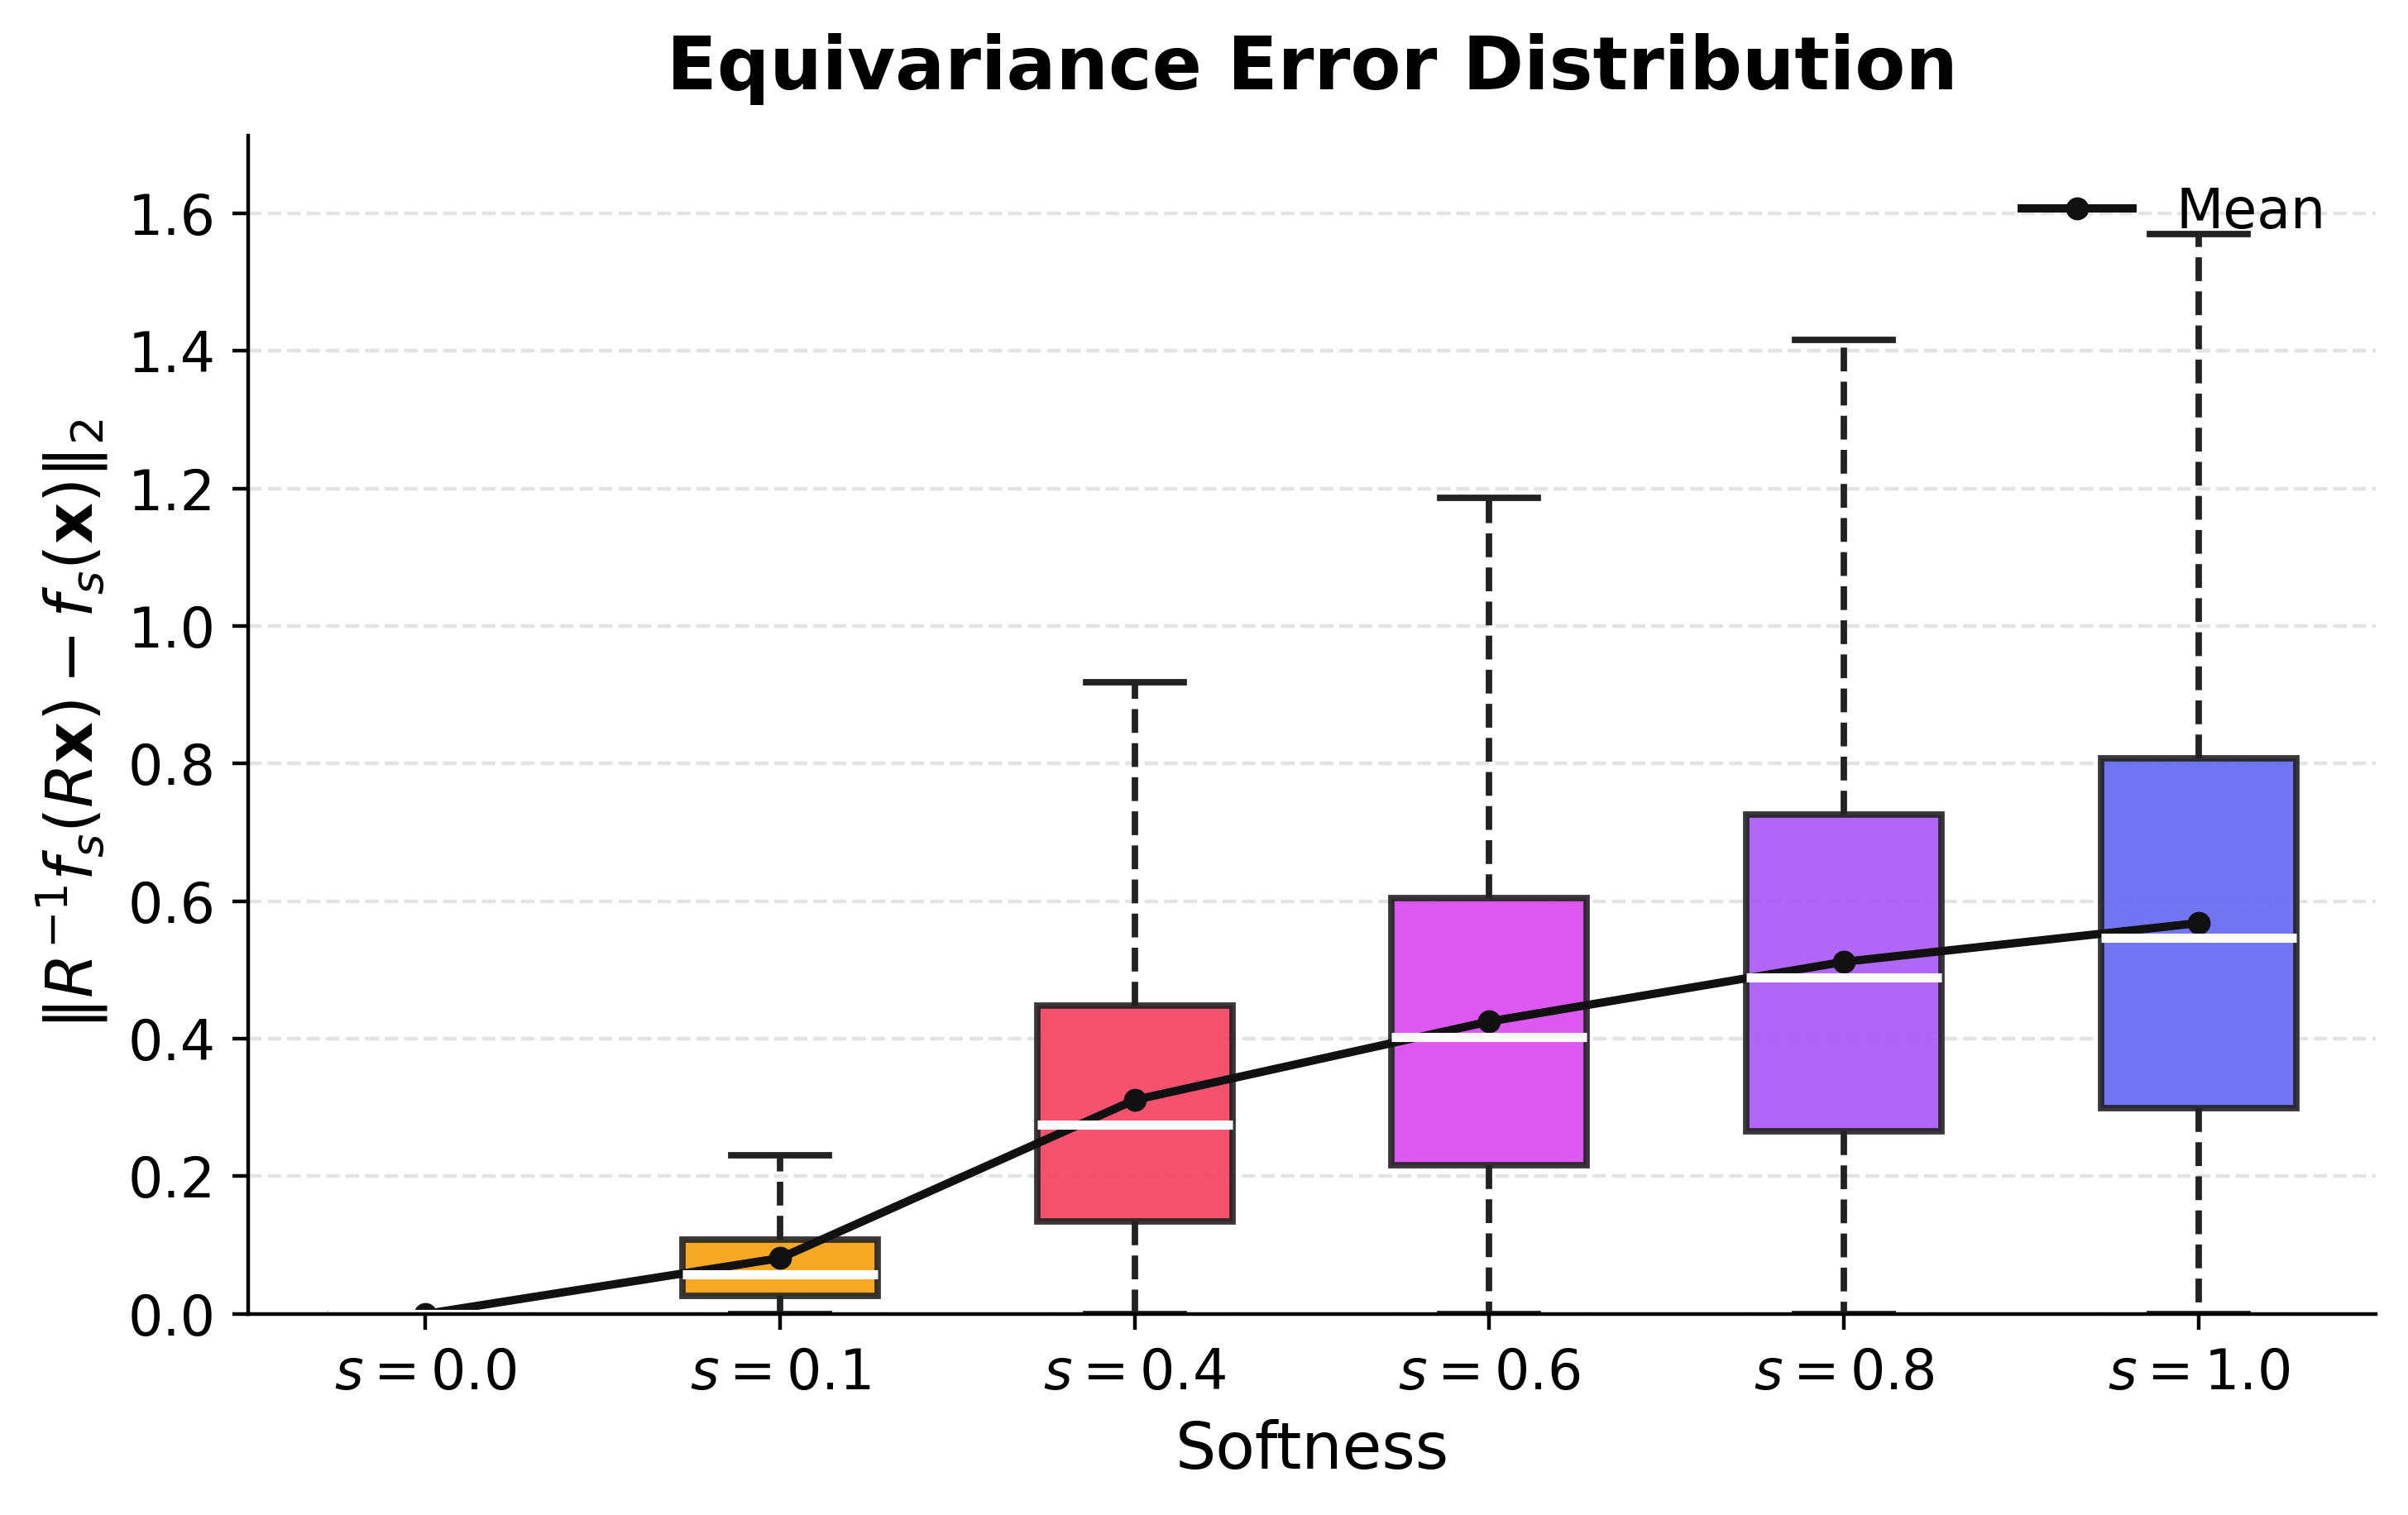

Saved: ./figs/equivariance_boxplot_static_600dpi.png


In [16]:
import numpy as np
import matplotlib.pyplot as plt

def save_static_boxplot(
    data_arrays,
    softness_vals,
    ylabel,
    title,
    out_path,
    dpi=600,
    figsize=(7.5, 4.8),
    colors=None,
):
    """
    data_arrays: list of 1D numpy arrays, one per softness value
    softness_vals: list like [0.0, 0.2, ...]
    """
    if colors is None:
        # paper-friendly palette
        colors = ['#10b981', '#f59e0b', '#f43f5e', '#d946ef', '#a855f7', '#6366f1'][:len(softness_vals)]

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    positions = np.arange(len(softness_vals))
    labels = [rf"$s={s:.1f}$" for s in softness_vals]

    bplot = ax.boxplot(
        data_arrays,
        positions=positions,
        widths=0.55,
        patch_artist=True,
        showfliers=False,  # better for paper readability
        medianprops=dict(color="white", linewidth=2.0),
        whiskerprops=dict(color="#222", linewidth=1.4, linestyle="--"),
        capprops=dict(color="#222", linewidth=1.4),
        boxprops=dict(edgecolor="#222", linewidth=1.4),
    )

    for patch, c in zip(bplot["boxes"], colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.9)

    # Optional: overlay mean marker
    means = [np.mean(a) for a in data_arrays]
    ax.plot(positions, means, color="#111", marker="o", linewidth=1.8, markersize=4, label="Mean")

    # Robust y-limit from 99th percentile
    y99 = max(np.percentile(a, 99) for a in data_arrays)
    ax.set_ylim(bottom=0, top=max(0.5, y99 * 1.2))

    ax.set_xticks(positions)
    ax.set_xticklabels(labels)
    ax.set_xlabel("Softness")
    ax.set_ylabel(ylabel)
    ax.set_title(title, pad=10, weight="bold")

    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(frameon=False, loc="upper right")
    fig.tight_layout()
    fig.savefig(out_path, dpi=dpi, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_path}")


# ---------- Example 1: Invariance static boxplot ----------
# Requires: global_errors_numpy and softness_vals from your invariance section
save_static_boxplot(
    data_arrays=global_errors_numpy,
    softness_vals=softness_vals,  # e.g., [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
    ylabel=r"$|f_s(R\mathbf{x}) - f_s(\mathbf{x})|$",
    title="Invariance Error Distribution",
    out_path="./figs/invariance_boxplot_static_600dpi.png",
    dpi=600,
)

# ---------- Example 2: Equivariance static boxplot ----------
# Requires: global_errors_eq_numpy and softness_vals from your equivariance section
# (if softness values differ there, pass that list instead)
save_static_boxplot(
    data_arrays=global_errors_eq_numpy,
    softness_vals=softness_vals,  # e.g., [0.0, 0.1, 0.4, 0.6, 0.8, 1.0]
    ylabel=r"$\|R^{-1}f_s(R\mathbf{x}) - f_s(\mathbf{x})\|_2$",
    title="Equivariance Error Distribution",
    out_path="./figs/equivariance_boxplot_static_600dpi.png",
    dpi=400,
)

##  Example Model

In [17]:
from utils.eq_nonlin import EQNonLin
from utils.eq_layernorm import EQLayerNorm

class DeepSO3InvariantModel(nn.Module):
    def __init__(self, n_vectors_in=5, hidden_vectors=[16, 16, 16], hidden_scalars=32, soft_threshold=0.0):
        """
        Multi-layer SO(3) invariant network.
        Sequence: 
        Input 
          -> [Equivariant Layer -> EQLayerNorm -> EQNonLin] x len(hidden_vectors) 
          -> Invariant Layer -> ReLU
          -> Linear -> Scalar Output
        """
        super().__init__()
        self.n_vectors_in = n_vectors_in
        self.soft_threshold = soft_threshold
        
        self.eq_layers = nn.ModuleList()
        self.eq_norms = nn.ModuleList()
        self.eq_acts = nn.ModuleList()
        
        # 1. Equivariant Stream
        curr_vecs = n_vectors_in
        for out_vecs in hidden_vectors:
            # Equivariant Linear mapping V -> V
            layer = create_so3_equivariant_layer(n_vectors_in=curr_vecs, 
                                                 n_vectors_out=out_vecs, 
                                                 soft_threshold=soft_threshold)
            self.eq_layers.append(layer)
            
            # Equivariant Normalization
            norm = EQLayerNorm([out_vecs * 3], dim=3)
            self.eq_norms.append(norm)
            
            # Equivariant Non-linearity (Norm-based ReLU)
            # dim=3 for SO(3) 3D vectors
            act = EQNonLin(dim=3, nonlinearity='relu', per_channel_bias=True, n_channels=out_vecs)
            self.eq_acts.append(act)
            
            curr_vecs = out_vecs
            
        # 2. Invariant Projection (V -> S)
        inv_filter = get_so3_invariant_filter(n_vectors_in=curr_vecs, soft_threshold=soft_threshold)
        self.inv_layer = FLinear(curr_vecs * 3, hidden_scalars, filter=inv_filter)
        self.inv_act = nn.ReLU()
        
        # 3. Final Scalar Transformation (S -> S)
        self.final_layer = nn.Linear(hidden_scalars, 1)

    def forward(self, x, return_stats=False):
        stats = {}
        if return_stats:
            stats['Input'] = {'mean': x.mean().item(), 'var': x.var().item(), 'std': x.std().item()}
            
        # Pass through sequential equivariant layers
        for i, (layer, norm, act) in enumerate(zip(self.eq_layers, self.eq_norms, self.eq_acts)):
            x = layer(x)
            if return_stats:
                stats[f'Eq_Linear_{i+1}'] = {'mean': x.mean().item(), 'var': x.var().item(), 'std': x.std().item()}
            
            # Norm layer expects 3D input: (Batch, Seq_len, Features)
            x_unsq = x.unsqueeze(1)
            x_normed = norm(x_unsq)
            x = x_normed.squeeze(1)
            if return_stats:
                stats[f'Eq_Norm_{i+1}'] = {'mean': x.mean().item(), 'var': x.var().item(), 'std': x.std().item()}

            x = act(x)
            if return_stats:
                stats[f'Eq_Act_{i+1}'] = {'mean': x.mean().item(), 'var': x.var().item(), 'std': x.std().item()}
            
        # Project down to invariances
        x = self.inv_layer(x)
        if return_stats:
            stats['Inv_Linear'] = {'mean': x.mean().item(), 'var': x.var().item(), 'std': x.std().item()}
            
        x = self.inv_act(x)
        if return_stats:
            stats['Inv_Act'] = {'mean': x.mean().item(), 'var': x.var().item(), 'std': x.std().item()}
        
        # Output invariant scalar
        out = self.final_layer(x)
        if return_stats:
            stats['Final_Output'] = {'mean': out.mean().item(), 'var': out.var().item(), 'std': out.std().item()}
            return out, stats
            
        return out

# --- Demonstrate the Deep Model ---

print("Building Deep SO(3) soft-invariant model...")
deep_model = DeepSO3InvariantModel(n_vectors_in=5, hidden_vectors=[16, 16, 16], soft_threshold=0.5) 
deep_model.eval()

print("Model Architecture Built Successfully!\n---")
print(deep_model)

# Sanity Check Demo
bs = 100
test_pts = generate_vector_set(n_vectors=5, batch_size=bs)
test_pts_flat = test_pts.view(bs, 15)

# Apply a random test rotation entirely
angle = np.random.uniform(0, 2*np.pi)
axis = np.random.randn(3); axis /= np.linalg.norm(axis)
R_test = get_rodrigues_rotation(axis, angle)

rot_test_pts = (test_pts @ R_test.T).contiguous().view(bs, 15)

# Check predictions and collect layer statistics
out_original, layer_stats = deep_model(test_pts_flat, return_stats=True)
out_rotated = deep_model(rot_test_pts)

# Measure Invariance error
diff = (out_original - out_rotated).abs().max().item()
print(f"\n[Test] Maximum difference between Deep f(x) and f(Rx) across {bs} batches: {diff:.6e}")

# Print out visually clean layer feature statistics
print("\n" + "="*52)
print("  HIDDEN FEATURE STATISTICS (Mean, Variance, Std)  ")
print("="*52)
print(f"{'Layer Name':<16} | {'Mean':>9} | {'Variance':>9} | {'Std Dev':>9}")
print("-" * 52)
for layer_name, stat in layer_stats.items():
    print(f"{layer_name:<16} | {stat['mean']:9.4f} | {stat['var']:9.4f} | {stat['std']:9.4f}")
print("="*52)

Building Deep SO(3) soft-invariant model...
last_basis_idx and total basis: tensor(398) 720
last_basis_idx and total basis: tensor(1278) 2304
last_basis_idx and total basis: tensor(1278) 2304
last_basis_idx and total basis: 22 48
Model Architecture Built Successfully!
---
DeepSO3InvariantModel(
  (eq_layers): ModuleList(
    (0-2): 3 x FLinear(
      (filter): MultiGeneratorEquivariantProjectorviaSVD(
        (invariant_projector): InvariantProjector()
      )
    )
  )
  (eq_norms): ModuleList(
    (0-2): 3 x EQLayerNorm()
  )
  (eq_acts): ModuleList(
    (0-2): 3 x EQNonLin(
      (act): ReLU()
    )
  )
  (inv_layer): FLinear(
    (filter): InvariantProjector()
  )
  (inv_act): ReLU()
  (final_layer): Linear(in_features=32, out_features=1, bias=True)
)

[Test] Maximum difference between Deep f(x) and f(Rx) across 100 batches: 2.643560e-01

  HIDDEN FEATURE STATISTICS (Mean, Variance, Std)  
Layer Name       |      Mean |  Variance |   Std Dev
----------------------------------------